In [ ]:
"""
Project Title: Elevation-based NDVI Analysis
Author: James McLoughlin
Date: May 2026
Description: This script processes DEM and Landsat data to calculate zonal statistics for vegetation health across different elevation zones.
"""

In [ ]:
# =============================================================================
# Library Imports
# =============================================================================
# Standard library imports
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)  # silences future development warninigs

# Geospatial and Data Science libraries
import earthaccess           # For NASA Earthdata access and authentication
import folium                # For interactive web map visualization
import geopandas as gpd      # For vector data manipulation
import numpy as np           # For numerical array operations
np.seterr(divide='ignore', invalid='ignore')  # silences mathetmatical warnings (e.g.divide by zero in indices like NDVI)

import pandas as pd          # For tabular data management and CSV export
from pathlib import Path     # For file path handling
import rasterio as rio       # Core library for reading and writing raster datasets
import rasterio.merge
from rasterio import features
from rasterio.merge import merge
from rasterio.windows import from_bounds
from rasterstats import zonal_stats # For calculating statistics within polygons
import rioxarray             # Extension for xarray to handle geospatial coordinates
import shapely               # For manipulation and analysis of geometric objects
from shapely.geometry import shape
import xarray as xr          # For handling multi-dimensional arrays
from xrspatial import hillshade # For terrain visualization
import matplotlib.pyplot as plt # For generating static plots and figures



# =============================================================================
# User Inputs and configuration
# =============================================================================
# Define the root directory for all project data to maintain relative paths
base = Path("C:/Users/jj_mc/OneDrive/Documents/GitHub/EGM722-Assessment/Data")

# Configuration dictionaries controlling which analysis and visualizations are processed
# 1 = Enable, 0 = Disable
ANALYSIS_OPTIONS = {
    "ndvi": 1,
    "ndwi": 0,
    "ndsi": 0
}

DISPLAY_OPTIONS = {
    "true_colour": 1,
    "false_colour": 0
}

# Defines vertical intervals for elevation analysis (meters)
step = 500

print("1. User Inputs and selections accepted")



# =============================================================================
# Predefined dictionary
# =============================================================================
# Maps specific tasks to the required spectral colours
# Allows script to load only necessary data for selected tasks
TASK_BANDS = {
    "true_colour" : ["red", "green","blue"],
    "false_colour" : ["nir","red","green"],
    "ndvi": ["red", "nir"],
    "ndwi": ["nir","green"],
    "ndsi": ["swir1","green"]
}



# =============================================================================
# Helper Functions
# =============================================================================
def raster_dataframe():
    """
    Searches a presepcified directory and sub directories to catalog Landsat 8 and 9 satellite imagery.
    
    This function iterates through specified data path, extracts image specific infotmation from 
    the Landsat filenames and maps bands the band number to the relative spectral color. It compiles 
    the information into a Pandas dataframe.

    Returns:
        pd.DataFrame: A DataFrame containing columns for filename, satellite ID, 
                      acquisition year, band ID, spectral colour, and file path.
    """
    records = []
    
    # a. Mapping Landsat 8/9 band identifiers to spectral colours 
    l8_9_bands = {
        "B1":"coast/aero", "B2":"blue", "B3":"green", "B4":"red", "B5":"nir", "B6":"swir1", "B7":"swir2"
    }
    
    # b. Iterates through folders within the configured Landsat data directory
    for folder in PATHS["landsat_data"].iterdir():
        if folder.is_dir():
            # Target Surface Reflectance (SR) TIF files
            for file in folder.glob("*_SR_B*.TIF"):
                parts = file.name.split("_")
                sat_id = parts[0][:4]  # Extract satellite ID, e.g. 'LC08'
                band_id = parts[-1].replace(".TIF", "")  # Extract band number, e.g. 'B1'

                # Assigns spectral color based on the satellite band mapping
                if sat_id in ["LC08", "LC09"]:
                    colour = l8_9_bands.get(band_id)

                # Only includes the files if the colour is required forthe study
                if colour in ALL_COLOURS:
                    records.append({
                        "filename": file.name,
                        "satellite": sat_id,
                        "year": parts[3][:4],
                        "band": band_id,
                        "colour": colour,
                        "path": str(file)
                    })
    
    # c. Return the collected metadata as a pandas DataFrame for analysis
    return pd.DataFrame(records)


    

def create_mosaic(file_list, out_path, dtype=None, nodata_val=None):
    """
    Merges multiple files into a single mosaicked image.

    Args:
        file_list (list): List of file paths (Path objects or strings) of the images to be merged.
        out_path (Path): Destination path for the generated mosaic (in .TIF formate).
        dtype (str, optional): Desired data type for output. Defaults to source dtype.
        nodata_val (float, optional): Value representing 'no data'. Defaults to source value.

    Returns:
        Path: The file path where the mosaic was successfully saved.
    """
    # a. Access the first file to establish baseline spatial metadata (CRS and Profile)    
    with rio.open(file_list[0]) as src:
        target_crs = src.crs
        out_meta = src.profile.copy()
        if nodata_val is None:
            nodata_val = src.nodata
        
    # b. Create the list of files to be merge.
    to_merge = []
    for f in file_list:
        with rio.open(f) as src:
                to_merge.append(f)
               
    # c. Mosiack the files, returns the combined array and new geotransform
    mosaic, out_trans = merge(to_merge, nodata=0)

    # d. File clean-up
    for s in to_merge:
        if hasattr(s, 'close'):
            s.close()
   
    # e. Synchronize metadata with the new mosaic dimensions and transformation
    bands, height, width = mosaic.shape
    out_meta.update({
        "height": height, 
        "width": width, 
        "transform": out_trans, 
        "nodata": 0,
        "dtype": dtype or out_meta['dtype']
    })

    # f. Write the array to disk
    with rio.open(out_path, "w", **out_meta) as dest:
        dest.write(mosaic)
    print(f"     Mosaic saved: {out_path.name}")
    return out_path   # path used to build the dataset used for analysis 



# =============================================================================
# Main Worflow
# =============================================================================

# --- 2. Create folder structure ---
# =============================================================================
# Define project directory strcutre using pathlib
PATHS = {
    "landsat_data" : base / "Landsat_Rasters",
    "mosaics": base / "Mosaics",
    "vectors": base / "Vector_Layers",
    "earthaccess": base / "EarthAccess",
    "results": base / "Results"
}

# Batch directory creation, and checks parent exisits to ensure full path creation 
for p in PATHS.values(): p.mkdir(parents=True, exist_ok=True)
print("2. Directories checked/created")



# --- 3. Determine colours bands required for selected tasks --- 
# =============================================================================
# Dictionary mapping selected analysis/outputs to their required spectral colours
TASK_BANDS = {
    "true_colour" : ["red", "green","blue"],
    "false_colour" : ["nir","red","green"],
    "ndvi": ["red", "nir"],
    "ndwi": ["nir","green"],
    "ndsi": ["swir1","green"]
}

# Identify active tasks by filtering through user-defined configuration  (where value == 1)
ANALYSIS_TASKS = [k for k, v in ANALYSIS_OPTIONS.items() if v == 1]
DISPLAY_TASKS = [k for k, v in DISPLAY_OPTIONS.items() if v == 1]

# Identify unique bands required across for analysis / display tasks, sets automatically handle de-duplication.
ANALYSIS_COLOURS = {band for task in ANALYSIS_TASKS for band in TASK_BANDS[task]}
DISPLAY_COLOURS = {band for task in DISPLAY_TASKS for band in TASK_BANDS[task]}

# Combine analysis and display colours into a master of unique colours using set union (|)
ALL_COLOURS = list(DISPLAY_COLOURS | ANALYSIS_COLOURS)
print("3. Band identification and mapping completed")



# --- 4. Build DataFrame of rasters needed for mosaicking ---
# =============================================================================
# Generate a Pandas dataframe of available local imagery matching the required bands
raster_df = raster_dataframe()

# Extract the year of the data being analysed
current_year = raster_df['year'].unique()[0]

# Export the dataframe to CSV
raster_df.to_csv(PATHS["landsat_data"] / f"{current_year}_raster_dataframe.csv", index=False)
print(F"4. Image dataset created : {len(raster_df)} files included")



# --- 5. Mosaick Rasters --- 
# =============================================================================
file_map = {}
print("5. Mosaicking started...")

# Group the dataframe by color to process all relevant tiles together
for colour, group in raster_df.groupby('colour'):
    # Extract file paths into a list for mosaicking
    file_list = group['path'].tolist()     
    
    # Define the output destination of the mosiac
    dst_path = PATHS["mosaics"] / f"{current_year}_{colour}_mosaic.tif"
    
    # Call mosaic function to merge tiles listed in file_lits
    # Returns the path of the mosaicked image, to populate file_map for use in Section 6
    mosaic_path = create_mosaic(file_list, dst_path, nodata_val=0)     
    
    # Store file path in a dictionary for easy access during Dataset assembly
    file_map[colour.lower()] = mosaic_path 

print("     All rasters mosaicked")



# --- 6. Build Dataset of Mosaicked Images ---
# =============================================================================
mosaic_list = []

# Iterate through the file-map established in the previous section
for name, path in file_map.items():
    
    # Load rasters using rioxarray with Dask-backed chunking.
    # Uses 'Lazy Loading' to process pieces of the raster as needed and prevent memory saturation.
    mosaic_da = rioxarray.open_rasterio(path, chunks={'x': 2048, 'y': 2048})
    
    # Pre-process DataArray for Dataset integration:
    # 1. .squeeze() removes the single 'band' dimension, resulting in a 2D array.
    # 2. .drop_vars() removes non-spatial coordinates that may conflict during merging.
    # 3. .rename() assigns the spectral band name (e.g., 'red') to the variable.
    mosaic_da = mosaic_da.squeeze().drop_vars('band', errors='ignore').rename(name)
    mosaic_list.append(mosaic_da)

# Combine individual arrays into a single multi-dimensional xarray Dataset
ds = xr.merge(mosaic_list)

print(f"6. Dataset for {current_year} completed")


    
# --- 7. Create Composite Images ---
# =============================================================================
print("7. Creating composite images")

# Iterate through each active display task (e.g., 'true_colour', 'false_colour')
for disp_tsk in DISPLAY_TASKS:
    
    # Slice the multi-variable Dataset to specific bands required for the task
    # .to_array() converts the specific bands raters into a multi-band composite
    img = ds[TASK_BANDS[disp_tsk]].to_array(dim='band')
    
    # Define destination for the composite array.
    img_dest = PATHS["results"] / f"{current_year}_{disp_tsk}_composite.tif"
    
    # Saves the array in a .tif format using the rioxarray extension
    img.rio.to_raster(img_dest)
    
    print(f"     Composite saved: {current_year} {disp_tsk}")
    

# # Iterate through each active display task (e.g., 'true_colour', 'false_colour')
# for disp_tsk in DISPLAY_TASKS:
    
#     # Slice the multi-variable Dataset to specific bands required for the task
#     # .to_array() converts the specific bands raters into a multi-band composite
#     img = ds[TASK_BANDS[disp_tsk]].to_array(dim='band')
    
#     # Define destination for the hi-res composite array and save it.
#     # tiled = True enable file to be opened quicker, compress="deflate" shrinks image file on disk 
#     img_dest_hi = PATHS["results"] / f"{current_year}_{disp_tsk}_composite_hi_res.tif"
#     img.rio.to_raster(img_dest_hi)#, tiled=True, compress="deflate")

#     # Create and save low-res version for easier viewing / manipulation. 
#     # Normalise the original composite from uint16 by converting to float32 and divding by 65535.0 
#     # Reduce resolution by a factor of 100, .mean() aveages resampling, type = uint8 futher reduces memory demands
#     img_converted = (img.astype("float32")/65535.0)
#     img_low_res = (img_converted.coarsen(x=10, y=10, boundary="trim").mean() * 255).astype("uint8")

#     # Define destination for the low-res composite array and save it.
#     img_dest_low = PATHS["results"] / f"{current_year}_{disp_tsk}_composite_low_res.tif"
#     img_low_res.rio.to_raster(img_dest_low)
#     print(f"     Composites saved: {current_year} {disp_tsk}")




    
        

# --- 8. NDVI and NDWI Analysis ---
# =============================================================================
# Tmo minmise memory usage reduce the rasters to the region of interst
# Locate and read the Region of Interest (ROI) vector file
roi = PATHS["vectors"] / "national_park_boundary.shp"
roi_gdf = gpd.read_file(roi)

# Reproject the ROI to match the dataset CRS
roi_gdf = roi_gdf.to_crs(ds.rio.crs)

# Clip the dataset to the ROI boundary and remove empty 'bounding box' pixels outside the polygon (drop=True)
ds_clipped = ds.rio.clip(roi_gdf.geometry, ds.rio.crs, drop=True) 

# Mask out zero values to avoid divisde by zero errors during calculation
ds_clean = ds_clipped.where(ds_clipped > 0)

# Iterate through active analysis tasks (e.g., NDVI, NDWI)
for task in ANALYSIS_TASKS: 
    # Retrieve required bands for the current index calculation
    b1_name = TASK_BANDS[task][0] 
    b2_name = TASK_BANDS[task][1] 

    # Concert to float to avoid calaucation errors (Landsat 8/9 repreaented as uint16)
    b1 = ds_clean[b1_name].astype(float)
    b2 = ds_clean[b2_name].astype(float)

    # Calaualted the Normalised Differnce Index
    ds_clipped[task] = (b2-b1)/(b2+b1)

    # Remove and points that have inf value (i.e. were /0)
    ds_clipped[task] = ds_clipped[task].where(np.isfinite(ds_clipped[task])) 
print("8. Normalized Difference Index Analysis Completed")



# --- 9. Acquire DEMs from Earth Access---
# =============================================================================
# DEMs required for elevation based analysis. ROI polygon used to spatially slect DEMs from NASA EarthAceess
# Reproject the ROI polygon to CRS requied for EarthAccess (EPSG:4326)
roi_4326 = roi_gdf.to_crs(epsg = 4326).union_all()

# Create mimnimum rotated retangle around ROI polygon (siple polygon needed for EarthAcress data search)
search_area = roi_4326.minimum_rotated_rectangle

# Change polygon vertices definiton to counter-clockwise orientation required by EarthAcess
search_area = shapely.geometry.polygon.orient(search_area, sign=1) 

print("9. EarthAccess data acquistion started...")

# Log into EarthAccess using credentials in local .netric file
earthaccess.login(strategy='netrc') 

# Searh the ASTER Global Digital Elevation Model (ASTGTM) collection
# Filter results using exterior coordinates of ROI's mimnimum rotated retangle
earthaccess_files = earthaccess.search_data( 
    short_name = 'ASTGTM',
    polygon = search_area.exterior.coords
)

# Execute batch download to the local pre-defined directory
earthaccess_dest = PATHS["earthaccess"]
downloaded_files = earthaccess.download(earthaccess_files, earthaccess_dest)



# --- 10. Mosaicking the DEMs ---
# =============================================================================
print("10. Mosaicking DEMs...")

# Filter the downloaded files to target only the Digital Elevation Model TIFs
dem_files = [fn for fn in downloaded_files if 'dem.tif' in fn.name]

# Define destination for the mosaikced DEM 
dem_mosaic_path = PATHS["mosaics"] / "DEM_mosaic.TIF" 

# Call 'create_mosaic' helper fuction to merge and save mosaic. 
create_mosaic(dem_files, dem_mosaic_path, dtype='float32')  #dtype set to 'float32' to minimise memory usage 



# --- 11. Vectorising Mosaicked DEM ---
# =============================================================================
# Extracting polygons from the DEM describing zones with different elevations
print("11. Vectorising DEM...")

# Load the DEM mosaic and remove the single band dimension
dem_master = rioxarray.open_rasterio(dem_mosaic_path).squeeze() 

# Align the ROI coordinate system to match the DEM for accurate clipping
roi_dem = roi_gdf.to_crs(dem_master.rio.crs)

# Clip the DEM to the ROI to minimise memory usage during vectorization
dem_clipped = dem_master.rio.clip(roi_dem.geometry, drop=True)

# Segment the elevation data into discrete elevation zones using floor division
# dtype "int32" used to minimise memory usage 
dem_segmented = (dem_clipped.values // step).astype("int32")

# Create a boolean mask to exclude NaN/NoData data from the vectorization
mask = ~np.isnan(dem_segmented)

# Extract vector shapes from the segmented raster data
shapes = features.shapes(dem_segmented, mask=mask,transform=dem_clipped.rio.transform())

polygons = [] 
for i, (geom, value) in enumerate(shapes): 
    # Scale segmented value back to true elevation and store with unique ID and geometry
    polygons.append({
        'poly_id': i,
        'elevation_zone': int(value * step), 
        'geometry': shape(geom)
    })

# Convert list of dictionaries into a GeoDataFrame using the clipped DEM's CRS
segments_gdf = gpd.GeoDataFrame(polygons, crs=dem_clipped.rio.crs)

# Reproject the polygons to match the Landsat CRS for consistent spatial analysis
segments_gdf = segments_gdf.to_crs(ds_clipped.rio.crs)

# Define output path and save the vector polygons as a .gpkg
output_path = PATHS["vectors"] / "elevation_zones.gpkg"
segments_gdf.to_file(output_path, driver="GPKG")

print("      Vectorising completed and saved")



# --- 12. Spatial Analysis & Data Integration ---
# =============================================================================
# Calculate zonal statistics for vegetation health (NDVI) across elevation zones
print("12. Calculating Zonal Statistics...")

# Extract the NDVI layer from dataset for the current year
ndvi_layer = ds_clipped.ndvi

# Execute zonal statistics to compute NDVI mean and standard deviation per polygon
stats = zonal_stats(
    segments_gdf,
    ndvi_layer.values,
    affine=ds_clipped.rio.transform(),
    stats=['mean', 'std'],
    nodata=np.nan,
    all_touched=True
)

# Convert statistics into a DataFrame and clean numeric types
stats_df = pd.DataFrame(stats)
stats_df['poly_id'] = segments_gdf['poly_id'] # Maintain link to polygons

# Join the statistics directly onto the GeoDataFrame for integrated storage
segments_gdf = segments_gdf.merge(stats_df, on='poly_id')

# Add metadata for temporal tracking
segments_gdf['year'] = current_year

# Save the integrated vector dataset (polygons + statistics) as a GeoPackage
output_file = PATHS["results"] / f"elevation_zones_with_stats_{current_year}.gpkg"
segments_gdf.to_file(output_file, driver="GPKG")

# Export a standalone CSV for reporting and non-spatial analysis
output_csv = PATHS["results"] / f"final_stats_{current_year}.csv"
segments_gdf.drop(columns='geometry').to_csv(output_csv, index=False)

print(f"      Zonal statistics integrated and saved")
print("--- Code completed ---")

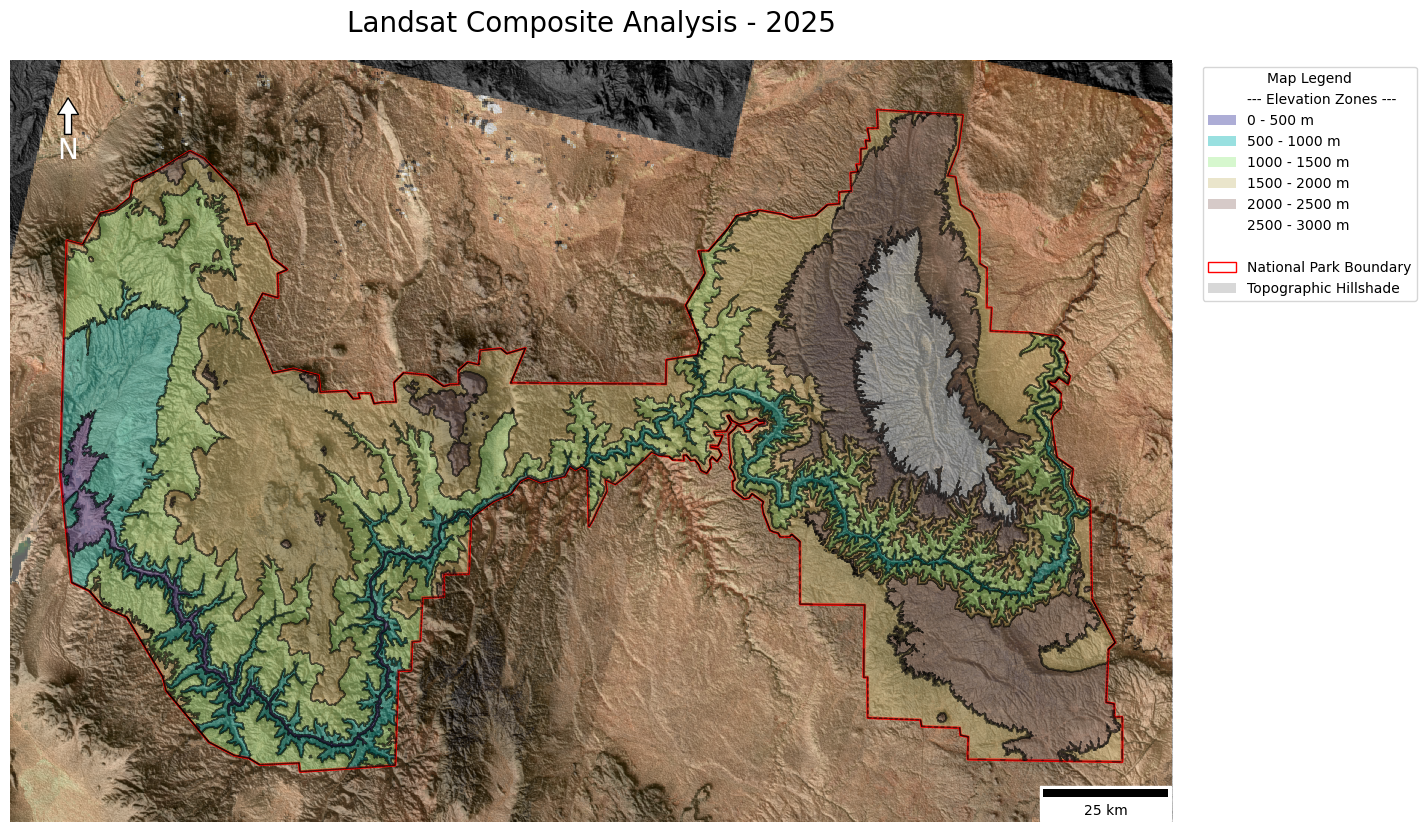

In [2]:
#import rasterio
#from rasterio.plot import show
from pathlib import Path     # For file path handling
import geopandas as gpd
import matplotlib.pyplot as plt
import rioxarray 
from matplotlib_scalebar.scalebar import ScaleBar
import matplotlib.patches as mpatches
# from shapely.geometry import box
from scipy.ndimage import gaussian_filter



# --- 1. Setting folder strcutre of files used for display ---
# =============================================================================
# Define the root directory for all project data to maintain relative paths
base = Path("C:/Users/jj_mc/OneDrive/Documents/GitHub/EGM722-Assessment/Data")
PATHS = {
    "mosaics": base / "Mosaics",
    "vectors": base / "Vector_Layers",
    "results": base / "Results"
}

gamma = 0.8
buffer = 10000
#step = 500


# --- 2. Processing Landsat Image and ROI ---
# =============================================================================
# Get crs of landsat image
img_path = PATHS['results']/"2025_true_colour_composite.tif"
with rioxarray.open_rasterio(img_path) as src:
    img_crs = src.rio.crs
    
# Load ROI, reproject to Landsat image, and extract ROI bounds
roi_raw = gpd.read_file(PATHS["vectors"] / "national_park_boundary.shp")
roi = roi_raw.to_crs(img_crs)
minx, miny, maxx, maxy = roi.total_bounds

# Add a buffer to ROI (meters)
bbox = [minx - buffer, miny - buffer, maxx + buffer, maxy + buffer]

# Open landsat imaage and immiatley clip to ROI buffer.
# Provides better quality redued data in memory
img = rioxarray.open_rasterio(img_path, mask_and_scale=True).rio.clip_box(*bbox)

# Adjust the colour balance, then rescale to increse memory efficiency
vmin, vmax = img.where(img > 0).quantile([0.05, 0.99]).compute()
img_scaled = ((img - vmin)/(vmax-vmin)*255).fillna(0).clip(0, 255)
img_scaled = (255 * (img_scaled / 255) ** gamma).fillna(0).astype("uint8")

# Downsample image for improved memory efficieny.
img_low_res = img_scaled.coarsen(x=10, y=10, boundary="trim").mean().astype("uint8")



# --- 3. Processing Hillshade ---
# =============================================================================
# Load hillshad, the match resolution and extent to the displyed landsat image
hillshade_raw = rioxarray.open_rasterio(PATHS['results']/"hillshade.tif")
hillshade = hillshade_raw.rio.reproject_match(img)
hs_array = hillshade.squeeze().astype("float32")

# Apply Gaussian blur to control hillshade smoothness
hs_smooth_array = gaussian_filter(hs_array, sigma=3)

# Return smoothed hillshade to Xarray DataArray to maintin coordinates
hs_smooth = hillshade.squeeze().copy(data=hs_smooth_array)



# --- 4. Load Spatial Data ---
# =============================================================================
spatial_data = gpd.read_file(PATHS["results"] /"elevation_zones_with_stats_2025.gpkg")
spatial_data_clipped = gpd.clip(spatial_data, roi)


# --- 5. Plotting ---
# =============================================================================
fig, ax = plt.subplots(figsize=(15, 15))

# Plot Landsat and hillshade underlay
img_low_res.plot.imshow(ax=ax)
hs_smooth.plot.imshow(ax=ax, cmap='gray', alpha=0.5, add_colorbar=False)

# Overlay ROI
roi.plot(ax=ax, facecolor='none', edgecolor='red', linewidth=2)

# Overlay: Elevation Bands
spatial_data_clipped.plot(ax=ax, column='elevation_zone', cmap='terrain', alpha=0.4, edgecolor='black')



# --- 6. Legend Construction ---
# =============================================================================
# Get unique elevation values and sort them ascending
unique_elevs = sorted(spatial_data_clipped['elevation_zone'].unique())

# Calculate step size
step = unique_elevs[1] - unique_elevs[0]   
    
unique_vals = sorted(spatial_data_clipped['elevation_zone'].unique())
cmap = plt.get_cmap('terrain')
norm = plt.Normalize(vmin=min(unique_vals), vmax=max(unique_vals))

# Initialize the list
legend_elements = []

# Add Elevation Subheading
legend_elements.append(mpatches.Patch(color='none', label='--- Elevation Zones ---'))

# Add each elevation step
for val in unique_vals:
    color = cmap(norm(val))
    label_text = f"{int(val)} - {int(val + step)} m" 
    legend_elements.append(mpatches.Patch(facecolor=color, alpha=0.4, label=label_text))


# Add a separator and the ROI Boundary
legend_elements.append(mpatches.Patch(color='none', label='')) # Spacer
legend_elements.append(mpatches.Patch(edgecolor='red', facecolor='none', label='National Park Boundary'))
legend_elements.append(mpatches.Patch(facecolor='gray', alpha=0.3, label='Topographic Hillshade'))


ax.legend(handles=legend_elements, loc='upper left', title="Map Legend", bbox_to_anchor=(1.02, 1), fontsize=10, frameon=True)



# --- 7. Map Elements ---
# =============================================================================
ax.add_artist(ScaleBar(1, units="m", location="lower right", frameon=True))
# North Arrow
x, y, arrow_length = 0.05, 0.95, 0.07
ax.annotate('N', xy=(0.05, 0.95), xytext=(0.05, 0.88),
            arrowprops=dict(facecolor='white', width=5, headwidth=15),
            ha='center', va='center', fontsize=20, color='white', xycoords='axes fraction')

ax.set_title("Landsat Composite Analysis - 2025", fontsize=20, pad=20)
ax.set_axis_off()

plt.show()


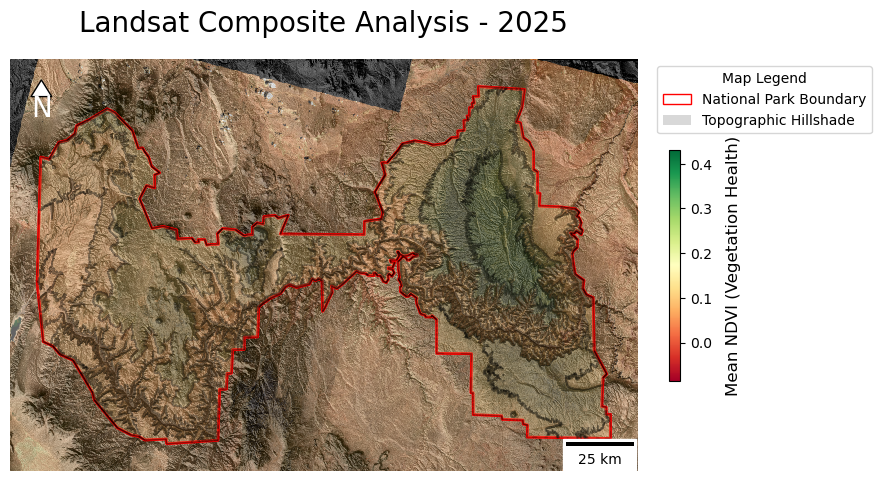

In [8]:
# Standard library imports
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)  # silences future development warninigs

#import rasterio
#from rasterio.plot import show
from pathlib import Path     # For file path handling
import geopandas as gpd
import matplotlib.pyplot as plt
import rioxarray 
from matplotlib_scalebar.scalebar import ScaleBar
import matplotlib.patches as mpatches
# from shapely.geometry import box
from scipy.ndimage import gaussian_filter


# --- 1. Setting folder strcutre of files used for display ---
# =============================================================================
# Define the root directory for all project data to maintain relative paths
base = Path("C:/Users/jj_mc/OneDrive/Documents/GitHub/EGM722-Assessment/Data")

PATHS = {
    "mosaics": base / "Mosaics",
    "vectors": base / "Vector_Layers",
    "results": base / "Results"
}

gamma = 0.8
buffer = 10000


# --- 2. Processing Landsat Image and ROI ---
# =============================================================================
# Get crs of landsat image
img_path = PATHS['results']/"2025_true_colour_composite.tif"
with rioxarray.open_rasterio(img_path) as src:
    img_crs = src.rio.crs
    
# Load ROI, reproject to Landsat image, and extract ROI bounds
roi_raw = gpd.read_file(PATHS["vectors"] / "national_park_boundary.shp")
roi = roi_raw.to_crs(img_crs)
minx, miny, maxx, maxy = roi.total_bounds

# Add a buffer to ROI (meters)
bbox = [minx - buffer, miny - buffer, maxx + buffer, maxy + buffer]

# Open landsat imaage and immiatley clip to ROI buffer.
# Provides better quality redued data in memory
img = rioxarray.open_rasterio(img_path, mask_and_scale=True).rio.clip_box(*bbox)

# Adjust the colour balance, then rescale to increse memory efficiency
vmin, vmax = img.where(img > 0).quantile([0.05, 0.99]).compute()
img_scaled = ((img - vmin)/(vmax-vmin)*255).clip(0, 255)
img_scaled = (255 * (img_scaled / 255) ** gamma).fillna(0).astype("uint8")

# Downsample image for improved memory efficieny.
img_low_res = img_scaled.coarsen(x=10, y=10, boundary="trim").mean().fillna(0).astype("uint8")



# --- 3. Processing Hillshade ---
# =============================================================================
# Load hillshad, the match resolution and extent to the displyed landsat image
hillshade_raw = rioxarray.open_rasterio(PATHS['results']/"hillshade.tif")
hillshade = hillshade_raw.rio.reproject_match(img)
hs_array = hillshade.squeeze().astype("float32")

# Apply Gaussian blur to control hillshade smoothness
hs_smooth_array = gaussian_filter(hs_array, sigma=3)

# Return smoothed hillshade to Xarray DataArray to maintin coordinates
hs_smooth = hillshade.squeeze().copy(data=hs_smooth_array)



# --- 4. Load Spatial Data ---
# =============================================================================
spatial_data = gpd.read_file(PATHS["results"] /"elevation_zones_with_stats_2025.gpkg")
spatial_data_clipped = gpd.clip(spatial_data, roi)


# --- 5. Plotting ---
# =============================================================================
fig, ax = plt.subplots(figsize=(10, 10))

# Plot Landsat and hillshade underlay
img_low_res.plot.imshow(ax=ax)
hs_smooth.plot.imshow(ax=ax, cmap='gray', alpha=0.5, add_colorbar=False)

# Overlay ROI
roi.plot(ax=ax, facecolor='none', edgecolor='red', linewidth=2)

# Overlay: Elevation Bands
spatial_data_clipped.plot(
    ax=ax, 
    column='mean',
    cmap='RdYlGn', 
    alpha=0.2, 
    edgecolor='black'
)



# --- 6. Legend Construction ---
# =============================================================================
# 1. Round NDVI values to 2dp FIRST to group similar values together
# This prevents the legend from having 100+ tiny redundant boxes
ndvi_rounded = spatial_data_clipped['mean'].round(2)
unique_vals = sorted(ndvi_rounded.unique())
cmap = plt.get_cmap('RdYlGn')
norm = plt.Normalize(vmin=spatial_data_clipped['mean'].min(), 
                      vmax=spatial_data_clipped['mean'].max())
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm._A = [] # Fake array for the mappable

# 2. Add the Colorbar to the figure
# shrink=0.5 makes it a nice size; pad adds a little space from the map
cbar = fig.colorbar(sm, ax=ax, shrink=0.3, pad=0.04)
cbar.set_label('Mean NDVI (Vegetation Health)', fontsize=12, labelpad=10)

# 3. Handle the single-item Legend (ROI and Hillshade)
# Since the scale is now a colorbar, the legend only needs the boundary line
legend_elements = []

# Add a separator and the ROI Boundary
legend_elements.append(mpatches.Patch(edgecolor='red', facecolor='none', label='National Park Boundary'))
legend_elements.append(mpatches.Patch(facecolor='gray', alpha=0.3, label='Topographic Hillshade'))

if len(legend_elements) > 25:
    legend_elements = legend_elements[::2] 

ax.legend(handles=legend_elements, loc='upper left', title="Map Legend", bbox_to_anchor=(1.02, 1), fontsize=10, frameon=True)

# --- 7. Map Elements ---
# =============================================================================
ax.add_artist(ScaleBar(1, units="m", location="lower right", frameon=True))
# North Arrow
x, y, arrow_length = 0.05, 0.95, 0.07
ax.annotate('N', xy=(0.05, 0.95), xytext=(0.05, 0.88),
            arrowprops=dict(facecolor='white', width=5, headwidth=15),
            ha='center', va='center', fontsize=20, color='white', xycoords='axes fraction')

ax.set_title("Landsat Composite Analysis - 2025", fontsize=20, pad=20)
ax.set_axis_off()

plt.show()

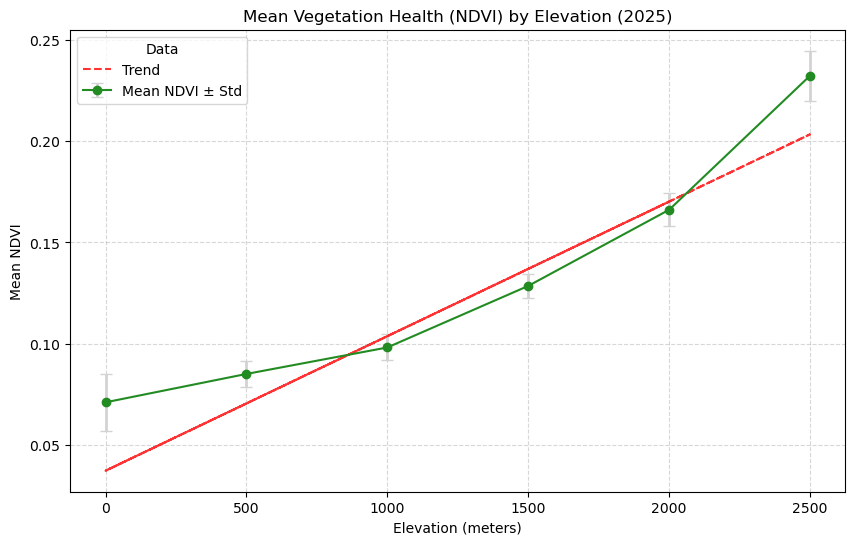

In [4]:
# 1. Load data
spatial_data = gpd.read_file(PATHS["results"]/"elevation_zones_with_stats_2025.gpkg")

# 2. Clean data: Remove rows where NDVI ('mean') is NaN
# This is usually why plots fail or look empty
plot_data = spatial_data.dropna(subset=['mean'])

# 1. Group the data by elevation zone
# We calculate the average of the polygon means and the average of their stds
elevation_profile = spatial_data.groupby('elevation_zone').agg({
    'mean': 'mean', 
    'std': 'mean'
}).reset_index().dropna()


# 3. Create the figure
plt.figure(figsize=(10, 6))


# Use errorbar to show the mean NDVI and the spread (std) for each zone
plt.errorbar(
    elevation_profile['elevation_zone'], 
    elevation_profile['mean'], 
    yerr=elevation_profile['std'], 
    fmt='o-',           # 'o' for points, '-' for connecting line
    color='forestgreen', 
    ecolor='lightgray', # Color of the error bars
    elinewidth=2, 
    capsize=4, 
    label='Mean NDVI ± Std'
)

# Optional: Add a trend line (simple linear fit)
import numpy as np
z = np.polyfit(plot_data['elevation_zone'], plot_data['mean'], 1)
p = np.poly1d(z)
plt.plot(plot_data['elevation_zone'], p(plot_data['elevation_zone']), "r--", alpha=0.8, label="Trend")

# Formatting
plt.title("Mean Vegetation Health (NDVI) by Elevation (2025)")
plt.xlabel("Elevation (meters)")
plt.ylabel("Mean NDVI")
plt.legend(title="Data")
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

In [ ]:
# #import rasterio
# #from rasterio.plot import show
# import geopandas as gpd
# import matplotlib.pyplot as plt
# import rioxarray 
# from matplotlib_scalebar.scalebar import ScaleBar
# import matplotlib.patches as mpatches
# from shapely.geometry import box
# from scipy.ndimage import gaussian_filter


# # --- 1. Setting folder strcutre of files used for display ---
# # =============================================================================
# PATHS = {
#     "mosaics": base / "Mosaics",
#     "vectors": base / "Vector_Layers",
#     "results": base / "Results"
# }

# gamma = 0.8
# buffer = 10000
# step = 500


# # --- 2. Processing Landsat Image and ROI ---
# # =============================================================================
# # Get crs of landsat image
# with rioxarray.open_rasterio(PATHS['results']/"2025_true_colour_composite.tif") as src:
#     img_crs = src.rio.crs
    
# # Load ROI, reproject to Landsat image, and extract ROI bounds
# roi_raw = gpd.read_file(PATHS["vectors"] / "national_park_boundary.shp")
# roi = roi_raw.to_crs(img_crs)
# minx, miny, maxx, maxy = roi.total_bounds

# # Add a buffer to ROI (meters)
# bbox = [minx - buffer, miny - buffer, maxx + buffer, maxy + buffer]

# # Open landsat imaage and immiatley clip to ROI buffer.
# # Provides better quality redued data in memory
# img = rioxarray.open_rasterio(
#     PATHS['results']/"2025_true_colour_composite_hi_res.tif", 
#     mask_and_scale=True
# ).rio.clip_box(*bbox)

# # Adjust the colour balance, then rescale to increse memory efficiency
# vmin, vmax = img.where(img > 0).quantile([0.05, 0.99]).compute()
# img_scaled = ((img - vmin)/(vmax-vmin)*255).clip(0, 255)
# img_scaled = (255 * (img_scaled / 255) ** gamma).astype("uint8")

# # Downsample image for improved memory efficieny.
# img_low_res = img_scaled.coarsen(x=10, y=10, boundary="trim").mean().astype("uint8")



# # --- 3. Processing Hillshade ---
# # =============================================================================
# # Load hillshad, the match resolution and extent to the displyed landsat image
# hillshade_raw = rioxarray.open_rasterio(PATHS['results']/"hillshade.tif")
# hillshade = hillshade_raw.rio.reproject_match(img)
# hs_array = hillshade.squeeze().astype("float32")

# # Apply Gaussian blur to control hillshade smoothness
# hs_smooth_array = gaussian_filter(hs_array, sigma=3)

# # Return smoothed hillshade to Xarray DataArray to maintin coordinates
# hs_smooth = hillshade.squeeze().copy(data=hs_smooth_array)



# # --- 4. Load Elevation Polygons ---
# # =============================================================================
# elevation_zones = gpd.read_file(PATHS["vectors"] /"elevation_zones.gpkg")
# elevation_zones_proj = elevation_zones.to_crs(roi.crs)
# elevation_zones_clipped = gpd.clip(elevation_zones_proj, roi)







# # --- 5. Plotting ---
# # =============================================================================
# fig, ax = plt.subplots(figsize=(15, 15))

# # Plot the Landsat Base
# img_low_res.plot.imshow(ax=ax)

# # Plot hillshade 
# #hillshade.squeeze().plot.imshow(ax=ax, cmap='gray', alpha=0.5, add_colorbar=False)
# hs_smooth.plot.imshow(ax=ax, cmap='gray', alpha=0.5, add_colorbar=False)

# # Plot ROI
# roi.plot(ax=ax, facecolor='none', edgecolor='red', linewidth=2)

# # Plot Elevation Zones with unique colors
# elevation_zones_clipped.plot(ax=ax, column='elevation_zone', cmap='terrain', alpha=0.4, edgecolor='black')




# # --- 6. Legend Construction ---
# # =============================================================================
# unique_elevs = sorted(elevation_zones_clipped['elevation_zone'].unique())
# cmap = plt.get_cmap('terrain')
# norm = plt.Normalize(vmin=min(unique_elevs), vmax=max(unique_elevs))

# # Initialize the list
# legend_elements = []

# # Add Elevation Subheading
# legend_elements.append(mpatches.Patch(color='none', label='--- Elevation Zones ---'))

# # Add each elevation step
# for val in unique_elevs:
#     color = cmap(norm(val))
#     label_text = f"{int(val)} - {int(val + step)} m" 
#     legend_elements.append(mpatches.Patch(facecolor=color, alpha=0.4, label=label_text))


# # Add a separator and the ROI Boundary
# legend_elements.append(mpatches.Patch(color='none', label='')) # Spacer
# #legend_elements.append(mlines.Line2D([0], [0], color='red', lw=2, label='National Park Boundary'))
# legend_elements.append(mpatches.Patch(edgecolor='red', facecolor='none', label='National Park Boundary')),
# legend_elements.append(mpatches.Patch(facecolor='gray', alpha=0.3, label='Topographic Hillshade'))


# ax.legend(handles=legend_elements, loc='upper left', title="Map Legend", bbox_to_anchor=(1.02, 1), fontsize=10, frameon=True)



# # --- 7. Map Elements ---
# # =============================================================================
# ax.add_artist(ScaleBar(1, units="m", location="lower right", frameon=True))
# # North Arrow
# x, y, arrow_length = 0.05, 0.95, 0.07
# ax.annotate('N', xy=(0.05, 0.95), xytext=(0.05, 0.88),
#             arrowprops=dict(facecolor='white', width=5, headwidth=15),
#             ha='center', va='center', fontsize=20, color='white', xycoords='axes fraction')

# ax.set_title("Landsat Composite Analysis - 2025", fontsize=20, pad=20)
# ax.set_axis_off()

# plt.show()


In [ ]:
# #import rasterio
# #from rasterio.plot import show
# import geopandas as gpd
# import matplotlib.pyplot as plt
# import rioxarray 
# from matplotlib_scalebar.scalebar import ScaleBar
# import matplotlib.patches as mpatches
# from shapely.geometry import box
# from scipy.ndimage import gaussian_filter


# # --- 1. Setting folder strcutre of files used for display ---
# # =============================================================================
# PATHS = {
#     "mosaics": base / "Mosaics",
#     "vectors": base / "Vector_Layers",
#     "results": base / "Results"
# }

# # --- 2. Processing Landsat Image ---
# # =============================================================================
# # Get crs of landsat image
# with rioxarray.open_rasterio(PATHS['results']/"2025_true_colour_composite_hi_res.tif") as src:
#     img_crs = src.rio.crs
    
# # Load ROI, reproject to Landsat image, and extract ROI bounds
# roi_raw = gpd.read_file(PATHS["vectors"] / "national_park_boundary.shp")
# roi = roi_raw.to_crs(img_crs)
# minx, miny, maxx, maxy = roi.total_bounds

# # Add a buffer to ROI (meters)
# buffer = 10000 
# bbox = [minx - buffer, miny - buffer, maxx + buffer, maxy + buffer]

# # Open landsat imaage and immiatley clip to ROI buffer.
# # Provides better quality redued data in memory
# img = rioxarray.open_rasterio(
#     PATHS['results']/"2025_true_colour_composite_hi_res.tif", 
#     mask_and_scale=True
# ).rio.clip_box(*bbox)

# # Adjust the colour balance, then rescale to increse memory efficiency
# gamma = 0.8
# vmin, vmax = img.where(img > 0).quantile([0.05, 0.99]).compute()
# img_scaled = ((img - vmin)/(vmax-vmin)*255).clip(0, 255)
# img_scaled = (255 * (img_scaled / 255) ** gamma).astype("uint8")

# # Downsample image for improved memory efficieny.
# img_low_res = img_scaled.coarsen(x=10, y=10, boundary="trim").mean().astype("uint8")



# # --- 3. Processing Hillshade ---
# # =============================================================================
# # Load hillshad, the match resolution and extent to the displyed landsat image
# hillshade_raw = rioxarray.open_rasterio(PATHS['results']/"hillshade.tif")
# hillshade = hillshade_raw.rio.reproject_match(img)
# hs_array = hillshade.squeeze().astype("float32")

# # Apply Gaussian blur to control hillshade smoothness
# hs_smooth_array = gaussian_filter(hs_array, sigma=3)

# # Return smoothed hillshade to Xarray DataArray to maintin coordinates
# hs_smooth = hillshade.squeeze().copy(data=hs_smooth_array)



# # --- 4. Load Elevation Polygons ---
# # =============================================================================
# elevation_zones = gpd.read_file(PATHS["vectors"] /"elevation_zones.gpkg")
# elevation_zones_proj = elevation_zones.to_crs(roi.crs)
# elevation_zones_clipped = gpd.clip(elevation_zones_proj, roi)




# # 5. Plotting
# fig, ax = plt.subplots(figsize=(15, 15))

# # Plot the Landsat Base
# img_low_res.plot.imshow(ax=ax)

# # Overlay Hillshade (alpha makes it look like a 3D texture)
# # hillshade.squeeze().plot.imshow(ax=ax, cmap='gray', alpha=0.5, add_colorbar=False)
# hs_smooth.plot.imshow(ax=ax, cmap='gray', alpha=0.5, add_colorbar=False)

# # Plot Vectors
# #elevation_zones.to_crs(img.rio.crs).plot(ax=ax, facecolor='none', edgecolor='lightblue', linewidth=0.5)
# #elevation_zones_clipped.plot(ax=ax, facecolor='none', edgecolor='lightblue', linewidth=0.5)
# elevation_zones_clipped.plot(ax=ax, column='elevation_zone', cmap='terrain', alpha=0.4, edgecolor='black')

# # 2. Get unique elevation values and the colormap
# unique_elevs = sorted(elevation_zones_clipped['elevation_zone'].unique())
# cmap = plt.get_cmap('terrain')
# # Normalize helps us pick the exact color from the cmap for each elevation value
# norm = plt.Normalize(vmin=min(unique_elevs), vmax=max(unique_elevs))

# # 3. Create a list of patches for each elevation step
# elevation_handles = []
# for val in unique_elevs:
#     color = cmap(norm(val))
#     # Assuming 'step' is your bin size (e.g., 100). If not defined, replace with your interval.
#     label_text = f"{int(val)} - {int(val + step)} m" 
    
#     elevation_handles.append(mpatches.Patch(
#         facecolor=color, 
#         alpha=0.4, 
#         label=label_text
#     ))

# # plot roi vector
# roi.to_crs(img.rio.crs).plot(ax=ax, facecolor='none', edgecolor='red', linewidth=2)

# # 4. Add ONLY the elevation legend to the plot
# ax.legend(
#     handles=elevation_handles, 
#     loc='upper left', 
#     title="Elevation Zones", 
#     bbox_to_anchor=(1.02, 1), # This moves the legend outside the plot so it doesn't block data
#     fontsize=10
# )



# legend_elements = []

# # Create a colored patch for every elevation band
# for val in unique_elevations:
#     color = cmap(norm(val))
#     legend_elements.append(mpatches.Patch(
#         facecolor=color, 
#         alpha=0.4, 
#         label=f"{int(val)}m - {int(val + step)}m"  # 'step' is your bin size from Section 11
#     ))

# # 3. Add the ROI Boundary to the list
# legend_elements.append(mpatches.Line2D([0], [0], color='red', lw=2, label='National Park Boundary'))

# # Scale Bar (Assumes UTM/Meters)
# ax.add_artist(ScaleBar(1, units="m", location="lower right", frameon=True))

# # North Arrow
# x, y, arrow_length = 0.05, 0.95, 0.07
# ax.annotate('N', xy=(x, y), xytext=(x, y - arrow_length),
#             arrowprops=dict(facecolor='black', width=5, headwidth=15),
#             ha='center', va='center', fontsize=20, xycoords='axes fraction')

# # Title and Custom Legend
# ax.set_title("Landsat Composite Analysis - 2025", fontsize=20, pad=20)

# legend_elements = [
#     mpatches.Patch(edgecolor='lightblue', facecolor='none', label='Elevation Zones'),
#     mpatches.Patch(edgecolor='red', facecolor='none', label='ROI Boundary'),
#     mpatches.Patch(facecolor='gray', alpha=0.3, label='Topographic Hillshade')
# ]
# ax.legend(handles=legend_elements, loc='upper right', fontsize=12)

# ax.set_axis_off()
# plt.show()


In [ ]:
# #import rasterio
# #from rasterio.plot import show
# import geopandas as gpd
# import matplotlib.pyplot as plt
# import rioxarray 
# from matplotlib_scalebar.scalebar import ScaleBar
# import matplotlib.patches as mpatches
# from shapely.geometry import box


# # User selects desred imgae type
# img_type = "2025_true_colour_composite_hi_res.tif"
# #img_type = "2025_false_colour_composite_hi_res.tif"
# #rioxarray.open_rasterio(PATHS['results']/"2025_true_colour_composite_hi_res.tif", mask_and_scale=True)
# #img = rioxarray.open_rasterio(PATHS['results']/"2025_false_colour_composite_hi_res.tif", mask_and_scale=True)


# # Directory strcutre of files used for display
# PATHS = {
#     "mosaics": base / "Mosaics",
#     "vectors": base / "Vector_Layers",
#     "results": base / "Results"
# }


# # Load image and vector files
# #img = rioxarray.open_rasterio(PATHS['results']/"2025_true_colour_composite_hi_res.tif", mask_and_scale=True)
# img = rioxarray.open_rasterio(PATHS['results']/img_type, mask_and_scale=True)
# #hillshade = rioxarray.open_rasterio(PATHS['results']/"hillshade.tif")
# roi = gpd.read_file(PATHS["vectors"] / "national_park_boundary.shp")
# elevation_zones = gpd.read_file(PATHS["vectors"] /"elevation_zones.gpkg")

# # Image colour balance adjustment and rescaling
# gamma = 0.8
# vmin, vmax = img.where(img > 0).quantile([0.05, 0.99]).compute()
# img_scaled = ((img - vmin)/(vmax-vmin)*255).clip(0, 255)
# img_scaled = (255 * (img_scaled / 255) ** gamma).astype("uint8")

# # Downsample for plotting
# img_low_res = img_scaled.coarsen(x=10, y=10, boundary="trim").mean().astype("uint8")

# # Load and Align Hillshade
# # Match resolution and extent of our low-res image for the overlay
# hillshade_raw = rioxarray.open_rasterio(PATHS['results']/"hillshade.tif")
# hillshade = hillshade_raw.rio.reproject_match(img)

# # 4. Load Vectors
# roi = gpd.read_file(PATHS["vectors"] / "national_park_boundary.shp")
# elevation_zones = gpd.read_file(PATHS["vectors"] /"elevation_zones.gpkg")

# # 5. Plotting
# fig, ax = plt.subplots(figsize=(15, 15))

# # Plot the Landsat Base
# img_low_res.plot.imshow(ax=ax)

# # Overlay Hillshade (alpha makes it look like a 3D texture)
# hillshade.squeeze().plot.imshow(ax=ax, cmap='gray', alpha=0.3, add_colorbar=False)

# # Plot Vectors
# elevation_zones.to_crs(img.rio.crs).plot(ax=ax, facecolor='none', edgecolor='lightblue', linewidth=0.5)
# roi.to_crs(img.rio.crs).plot(ax=ax, facecolor='none', edgecolor='red', linewidth=2)

# # Scale Bar (Assumes UTM/Meters)
# ax.add_artist(ScaleBar(1, units="m", location="lower right", frameon=True))

# # North Arrow
# x, y, arrow_length = 0.05, 0.95, 0.07
# ax.annotate('N', xy=(x, y), xytext=(x, y - arrow_length),
#             arrowprops=dict(facecolor='black', width=5, headwidth=15),
#             ha='center', va='center', fontsize=20, xycoords='axes fraction')

# # Title and Custom Legend
# ax.set_title("Landsat Composite Analysis - 2025", fontsize=20, pad=20)

# legend_elements = [
#     mpatches.Patch(edgecolor='lightblue', facecolor='none', label='Elevation Zones'),
#     mpatches.Patch(edgecolor='red', facecolor='none', label='ROI Boundary'),
#     mpatches.Patch(facecolor='gray', alpha=0.3, label='Topographic Hillshade')
# ]
# ax.legend(handles=legend_elements, loc='upper right', fontsize=12)

# ax.set_axis_off()
# plt.show()







# # # 2. Plot Vectors with Labels for Legend
# # elevation_zones.plot(ax=ax, facecolor='none', edgecolor='lightblue', linewidth=0.5, label="Elevation Zones")
# # roi.to_crs(img.rio.crs).plot(ax=ax, facecolor='none', edgecolor='red', linewidth=2, label="ROI Boundary")

 
# # # 3. Scale Bar
# # # Uses the units from your CRS (usually meters for UTM)
# # ax.add_artist(ScaleBar(1, units="m", location="lower right", frameon=True))

# # # 4. North Arrow
# # x, y, arrow_length = 0.05, 0.95, 0.07
# # ax.annotate('N', xy=(x, y), xytext=(x, y - arrow_length),
# #             arrowprops=dict(facecolor='black', width=5, headwidth=15),
# #             ha='center', va='center', fontsize=20, xycoords='axes fraction')

# # # 5. Title and Legend
# # ax.set_title(f"Landsat Composite Analysis - 2025", fontsize=20)

# # # Create custom legend handles since GeoPandas 'label' doesn't always auto-populate
# # elev_patch = mpatches.Patch(edgecolor='lightblue', facecolor='none', label='Elevation Zones')
# # roi_patch = mpatches.Patch(edgecolor='red', facecolor='none', label='ROI Boundary')
# # ax.legend(handles=[elev_patch, roi_patch], loc='upper right', fontsize=12)

# # # Cleanup axes (optional)
# # ax.set_axis_off()

# # plt.show()



# # # fig, ax = plt.subplots(figsize=(15, 15))
# # # img_low_res.plot.imshow(ax=ax)
# # # segments_gdf.plot(ax=ax, facecolor ='none',edgecolor ='lightblue',linewidth=0.5)
# # # roi_gdf.to_crs(ds.rio.crs).plot(ax=ax, facecolor='none', edgecolor='red', linewidth=2)

# # plt.show()

In [ ]:
# #import rasterio
# #from rasterio.plot import show
# import geopandas as gpd
# import matplotlib.pyplot as plt
# import rioxarray 
# from matplotlib_scalebar.scalebar import ScaleBar
# import matplotlib.patches as mpatches

# # User selects desred imgae type
# #img_type = "2025_true_colour_composite_hi_res.tif"
# #img_type = "2025_false_colour_composite_hi_res.tif"

# img = rioxarray.open_rasterio(PATHS['results']/"2025_true_colour_composite_hi_res.tif", mask_and_scale=True)
# #img = rioxarray.open_rasterio(PATHS['results']/"2025_false_colour_composite_hi_res.tif", mask_and_scale=True)






# # Define project directory strcutre using pathlib
# PATHS = {
#     "mosaics": base / "Mosaics",
#     "vectors": base / "Vector_Layers",
#     "results": base / "Results"
# }

# # Read in files for plotting
# #img = rioxarray.open_rasterio(PATHS['results']/ img_type, mask_and_scale=True)
# hillshade = rioxarray.open_rasterio(PATHS['results']/"hillshade.tif")
# roi = gpd.read_file(PATHS["vectors"] / "national_park_boundary.shp")
# elevation_zones = gpd.read_file(PATHS["vectors"] /"elevation_zones.gpkg")

# # Image colout balance adjustment and size rescaling 
# gamma = 0.8
# vmin, vmax = img.where(img > 0).quantile([0.05, 0.99]).compute()
# img_scaled = ((img - vmin)/(vmax-vmin)*255).clip(0, 255)
# img_scaled = (255 * (img_scaled / 255) ** gamma).astype("uint8")
# img_low_res = img_scaled.coarsen(x=10, y=10, boundary ="trim").mean().astype("uint8")


# #plotting images 
# fig, ax = plt.subplots(figsize=(15, 15))

# # 1. Plot the Image
# img_low_res.plot.imshow(ax=ax)
# hillshade.plot.imshow(ax=ax, cmap='gray', alpha=0.4)#, extent=img_extent)

# # 2. Plot Vectors with Labels for Legend
# elevation_zones.plot(ax=ax, facecolor='none', edgecolor='lightblue', linewidth=0.5, label="Elevation Zones")
# roi.to_crs(img.rio.crs).plot(ax=ax, facecolor='none', edgecolor='red', linewidth=2, label="ROI Boundary")
 
# # 3. Scale Bar
# # Uses the units from your CRS (usually meters for UTM)
# ax.add_artist(ScaleBar(1, units="m", location="lower right", frameon=True))

# # 4. North Arrow
# x, y, arrow_length = 0.05, 0.95, 0.07
# ax.annotate('N', xy=(x, y), xytext=(x, y - arrow_length),
#             arrowprops=dict(facecolor='black', width=5, headwidth=15),
#             ha='center', va='center', fontsize=20, xycoords='axes fraction')

# # 5. Title and Legend
# ax.set_title(f"Landsat Composite Analysis - 2025", fontsize=20)

# # Create custom legend handles since GeoPandas 'label' doesn't always auto-populate
# elev_patch = mpatches.Patch(edgecolor='lightblue', facecolor='none', label='Elevation Zones')
# roi_patch = mpatches.Patch(edgecolor='red', facecolor='none', label='ROI Boundary')
# ax.legend(handles=[elev_patch, roi_patch], loc='upper right', fontsize=12)

# # Cleanup axes (optional)
# ax.set_axis_off()

# plt.show()



# # fig, ax = plt.subplots(figsize=(15, 15))
# # img_low_res.plot.imshow(ax=ax)
# # segments_gdf.plot(ax=ax, facecolor ='none',edgecolor ='lightblue',linewidth=0.5)
# # roi_gdf.to_crs(ds.rio.crs).plot(ax=ax, facecolor='none', edgecolor='red', linewidth=2)

# # plt.show()

In [ ]:
# import rasterio
# from rasterio.plot import show
# import geopandas as gpd
# import matplotlib.pyplot as plt
# import rioxarray 


# # Load the desired composite image
# COMP_TYPE = 
# img_type = '2025_true_colour_composite_hi_res.tif"
# img_type = '2025_false_colour_composite_hi_res.tif"
# img = rioxarray.open_rasterio(PATHS['results']/"2025_true_colour_composite_hi_res.tif", mask_and_scale=True)

# gamma = 0.8


# vmin, vmax = img.where(img > 0).quantile([0.05, 0.99]).compute()
# img_scaled = ((img - vmin)/(vmax-vmin)*255).clip(0, 255)
# img_scaled = (255 * (img_scaled / 255) ** gamma).astype("uint8")
# img_low_res = img_scaled.coarsen(x=10, y=10, boundary ="trim").mean().astype("uint8")


# fig, ax = plt.subplots(figsize=(15, 15))

# img_low_res.plot.imshow(ax=ax)
    
# # 2. Display the raster (e.g., using the first three bands for RGB)
# # Use transform=src.transform to keep the plot in map coordinates
# #show(src, ax=ax, title="Landsat Overlay")


# segments_gdf.plot(ax=ax, facecolor ='none',edgecolor ='lightblue',linewidth=0.5)
# roi_gdf.to_crs(ds.rio.crs).plot(ax=ax, facecolor='none', edgecolor='red', linewidth=2)

# plt.show()

In [ ]:
# import rioxarray
# import xarray as xr
# import matplotlib.pyplot as plt
# import numpy as np

# # Define project directory strcutre using pathlib
# PATHS = {
#     "mosaics": base / "Mosaics",
#     "vectors": base / "Vector_Layers",
#     "results": base / "Results"
# }

#         # img = ds[INDEX_TO_BANDS[disp_tsk]].sel(year=year).to_array(dim='band')
#         # #vimn, vmax = img.min(), img.max()
#         # #vmin, vmax = img.quantile([0.02, 0.98]).compute()
#         # vmin, vmax = img.where(img > 0).quantile([0.05, 0.99]).compute()
#         # img_scaled = ((img - vmin)/(vmax-vmin)*255).clip(0, 255)
#         # img_scaled = (255 * (img_scaled / 255) ** gamma).astype("uint8")
#         # img_low_res = img_scaled.coarsen(x=10, y=10, boundary ="trim").mean().astype("uint8")
#         # img_dest = PATHS["results"] / f"{year}_{disp_tsk}_composite.tif"
#         # img_low_res.rio.to_raster(img_dest)
#         # print(f"Saved: {img_dest.name}") 


# # 1. Open the image
# # 'mask_and_scale=True' automatically converts nodata to NaN
# ds = rioxarray.open_rasterio(PATHS['results']/"2025_true_colour_composite_hi_res.tif", mask_and_scale=True)

# # 2. Color Balance (Calculate quantiles across the whole spatial extent)
# vmin = ds.quantile(0.02)
# vmax = ds.quantile(0.98)

# # 3. Scale and Apply Gamma
# gamma = 0.8
# img_scaled = ((ds - vmin) / (vmax - vmin)).clip(0, 1)
# img_scaled = np.power(img_scaled, gamma).astype("uint8")

# img_low_res = img_scaled.coarsen(x=10, y=10, boundary ="trim").mean().astype("uint8")

# # 4. Plot
# fig, ax = plt.subplots(figsize=(15, 15))

# # Xarray's .plot.imshow handles the coordinates and RGB conversion automatically


# # 5. Overlay Polygons (matches the CRS automatically from the DataArray)
# segments_gdf.to_crs(ds.rio.crs).plot(ax=ax, facecolor ='none',edgecolor ='lightblue',linewidth=0.5)
# roi_gdf.to_crs(ds.rio.crs).plot(ax=ax, facecolor='none', edgecolor='red', linewidth=2)

# plt.show()

In [ ]:
# dem_path = PATHS["mosaics"] / "DEM_mosaic.TIF"
# with rio.open(dem_path) as src:
#     dem = src.read(1)
#     out_meta = src.meta.copy()
# elevation_da = xr.DataArray(dem, dims=['y', 'x'])
# illuminated = hillshade(elevation_da, azimuth=315, angle_altitude=45)
# out_filename = PATHS["results"] / "hillshade.tif"
# with rio.open(out_filename, 'w', **out_meta) as dst:
#     dst.write(illuminated, 1)
# print('data saved')                
# #plt.imshow(illuminated, cmap='Greys')
# #plt.show

In [ ]:
# import rasterio
# from rasterio.plot import show
# import geopandas as gpd
# import matplotlib.pyplot as plt
# import rioxarray 

# gamma = 0.8
# # for year in df["year"].unique():
# #     for disp_tsk in DISPLAY_TASKS:
# img = rioxarray.open_rasterio(PATHS['results']/"2025_true_colour_composite_hi_res.tif", mask_and_scale=True)
# #img = ds[INDEX_TO_BANDS[disp_tsk]].sel(year=year).to_array(dim='band')
# #vimn, vmax = img.min(), img.max()
# #vmin, vmax = img.quantile([0.02, 0.98]).compute()
# vmin, vmax = img.where(img > 0).quantile([0.05, 0.99]).compute()
# img_scaled = ((img - vmin)/(vmax-vmin)*255).clip(0, 255)
# img_scaled = (255 * (img_scaled / 255) ** gamma).astype("uint8")
# img_low_res = img_scaled.coarsen(x=10, y=10, boundary ="trim").mean().astype("uint8")
# #img_dest = PATHS["results"] / f"{year}_{disp_tsk}_composite.tif"
# #img_low_res.rio.to_raster(img_dest)
# #print(f"Saved: {img_dest.name}") 

        
# #landsat_image = PATHS['results']/"2025_true_colour_composite.tif"
# #polygons = PATHS['results']/"final_vegetation_stats.csv"
# # 1. Open the Landsat raster
# with rasterio.open(landsat_image) as src:
#     fig, ax = plt.subplots(figsize=(15, 15))
    
#     # 2. Display the raster (e.g., using the first three bands for RGB)
#     # Use transform=src.transform to keep the plot in map coordinates
#     show(src, ax=ax, title="Landsat Overlay")

#     # 3. Load and reproject your polygon dataframe
#     roi_4326 = roi_gdf.to_crs(epsg = 26912)
# #    gdf = gpd.read_file(polygons)
# #    gdf = gdf.to_crs(src.crs) # Vital for alignment

#     # 4. Overlay the polygons
#     segments_gdf.plot(ax=ax, facecolor ='none',edgecolor ='lightblue',linewidth=0.5)
#     roi_4326.plot(ax=ax, facecolor='none', edgecolor='red', linewidth=2)

# plt.show()

In [ ]:
# ## backup hillsdahes that worked


# print("8. DEM mosaicking started...")
# dem_files = [fn for fn in downloaded_files if 'dem.tif' in fn.name]
# dem_mosaic_dest = PATHS["earthaccess"] / "DEM_mosaic.TIF"
# dem_meta = create_mosaic(dem_files, dem_mosaic_dest, dtype='float32')
# dem_ds = xr.Dataset({"elevation":dem_windowed})
# dem_ds = dem_ds.rio.write_crs(win_meta['crs']).rio.write_transform(win_meta['transform'])
# dem_ds_clipped = dem_ds.rio.clip(border_gdf_proj.geometry, drop =True)
# hillshade_orig = hillshade(dem_ds, azimuth=225, angle_altitude=45)
# hillshade_26912 = hillshade_orig.rio.reproject("EPSG:26912")
# hillshade_dest = PATHS["results"] / "hillshade.tif"
# hillshade_26912.rio.to_raster(hillshade_dest, compress = "lzw")

# # --- 7. Creating Hillshde
# hillshade = hillshade(dem_ds, azimuth=335, angle_altitude=45)
# #hillshade_26912 = hillshade_orig.rio.reproject("EPSG:26912")
# hillshade_dest = PATHS["results"] / "Hillshade.tif"
# #hillshade_26912.rio.to_raster(hillshade_dest, compress = "lzw")

In [ ]:
gamma = 0.8
# for year in df["year"].unique():
#     for disp_tsk in DISPLAY_TASKS:
img = ds[INDEX_TO_BANDS[disp_tsk]].sel(year=year).to_array(dim='band')
#vimn, vmax = img.min(), img.max()
#vmin, vmax = img.quantile([0.02, 0.98]).compute()
vmin, vmax = img.where(img > 0).quantile([0.05, 0.99]).compute()
img_scaled = ((img - vmin)/(vmax-vmin)*255).clip(0, 255)
img_scaled = (255 * (img_scaled / 255) ** gamma).astype("uint8")
img_low_res = img_scaled.coarsen(x=10, y=10, boundary ="trim").mean().astype("uint8")
img_dest = PATHS["results"] / f"{year}_{disp_tsk}_composite.tif"
img_low_res.rio.to_raster(img_dest)
print(f"Saved: {img_dest.name}")    


scale = 2
img = rioxarray.open_rasterio(PATHS["results"]/"2020_true_colour_composite.tif")
img_height_new = int(img.rio.height / scale)
img_width_new = int(img.rio.width / scale)
img_scaled = img.rio.reproject('EPSG:4326', shape=(img_height_new,img_width_new))
b = img_scaled.rio.bounds()
img_bounds_folium = [[b[1],b[0]],[b[3],b[2]]]
img_data = img_scaled.transpose('y','x','band').values
#if img_data.max() <= 1.0:
#    img_data = (img_data * 255).astype('uint8')
alpha = np.where(img_data.sum(axis=-1) > 0, 255, 0).astype('uint8')
img_data_rgba = np.dstack((img_data, alpha))

hill = rioxarray.open_rasterio(PATHS["results"]/"terrain_hillshade_high_res.tif")
hill_height_new = int(hill.rio.width / scale)
hill_width_new = int(hill.rio.width / scale)
hill_scaled = hill.rio.reproject('EPSG:4326', shape=(hill_height_new,hill_width_new))
h = hill_scaled.rio.bounds()
hill_bounds_folium = [[h[1],h[0]],[h[3],h[2]]]
hill_data_2d = hill_scaled.values.squeeze()
#beta = np.where(hill_data.sum(axis=-1) > 0, 255, 0).astype('uint8')
#hill_data_2d = np.dstack((hill_data, beta))



m = folium.Map([36.15, -112.7],tiles="USGS.USImagery")
folium.raster_layers.ImageOverlay(
    name = "True Colour Overaly",
    image = img_data_rgba,
    bounds = img_bounds_folium,
).add_to(m)
folium.raster_layers.ImageOverlay(
    name = "Hillshade Overaly",
    image = hill_data_2d,
    bounds = hill_bounds_folium,
    opacity = 0.4    
).add_to(m)

folium.LayerControl().add_to(m)
m

In [ ]:
# # Create a mask for the river
# river_mask = ds_clipped['ndwi'].isel(year=0) > 0.1
# # Apply this to NDVI to analyze only 'Land' pixels
# ndvi_land_only = ds_clipped['ndvi'].where(~river_mask)

# def mask_from_raster(year, pathrow, NDI):#, river_ref_path):
#     poly_list = []
#     file = NDI_data/f"{year}_{pathrow}_{NDI}.tif"
#     with rio.open(file) as src:
#         non_binary = src.read(1)
#         mask = np.where(non_binary > -0.1 , 255 ,0).astype("uint8")
#         cleaned_mask = sieve(mask,50)
#         out_meta = src.meta.copy()
#         out_meta.update(dtype = "uint8", nodata = 0)
#         mask_out = masks / f"{year}_{pathrow}_{NDI}.tif"
        
#         with rio.open(mask_out, "w", **out_meta) as dst:
#             dst.write(cleaned_mask,1)

#     file = mask_data / f"{year}_{pathrow}_{NDI}.tif"
#     with rio.open(file) as src:
#         tile = src.read(1).astype("int16")
#         out_meta = src.meta.copy()
#         mask_shapes = features.shapes(
#             tile,
#             mask = tile > 0,
#             transform = out_meta['transform']
#         )
#     # The corrected list comprehension
#     polygons = [
#     {'geometry':shape(s),'properties':{'id': i}}
#      for i, (s,v) in enumerate(mask_shapes)
#     ]
              
#     gdf = gpd.GeoDataFrame.from_features(polygons, crs=out_meta['crs'])
#     return gdf

    